**SETUP**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Use a clean, publication-style look
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 14,
    'axes.labelweight': 'bold',
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 8.5,
    "legend.title_fontsize": 8.5,
    "figure.figsize": (3.3, 2.5),  # fits IEEE column width (~3.5 inches)
    "axes.linewidth": 0.6,
    'figure.dpi': 300,
})

**EXPERIMENT RESULTS**

In [3]:
results_path = "../results/med_home1907_8kwpv_1/20260424_115721_start10,3,22_batt76.1_8kwpv_med_1907"

In [4]:
summary_df = pd.read_csv(f"{results_path}/summary.csv")
summary_df

,method,exp_name,energy_cost,batt_deg_cost,total_cost
0,no_v2g,"med_home1907_8kwpv_1_10,3,22",4.079031,0.000000,4.079031
1,rulebased,"med_home1907_8kwpv_1_10,3,22",4.478363,0.034324,4.512687
2,nsga,"med_home1907_8kwpv_1_10,3,22",5.086027,0.002658,5.088685


In [5]:
timeseries_df = pd.read_parquet(f"{results_path}/timeseries.parquet", engine='pyarrow')
timeseries_df.head(30)

,exp_name,energy prices,no_v2g_charging_schedule,no_v2g_net_load,no_v2g_socs,no_v2g_sohs,no_v2g_dods,rulebased_charging_schedule,rulebased_net_load,rulebased_socs,rulebased_sohs,rulebased_dods,nsga_charging_schedule,nsga_net_load,nsga_socs,nsga_sohs,nsga_dods
0,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.940078,0.100791,0.951599,0.899209,2.75,-2.940078,0.100791,0.951599,0.899209,2.693150,2.882653,0.100791,0.951599,0.899209
1,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-3.191778,0.300000,0.951599,0.700000,2.75,-3.191778,0.136928,0.951599,0.863072,2.394491,2.832678,0.136181,0.951599,0.863819
2,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.933478,0.336137,0.951599,0.663863,2.75,-2.933478,0.173064,0.951599,0.826936,0.987579,1.153255,0.167646,0.951599,0.832354
3,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.931378,0.372273,0.951599,0.627727,2.75,-2.931378,0.209201,0.951599,0.790799,2.702085,2.882978,0.180623,0.951599,0.819377
4,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.921878,0.408410,0.951599,0.591590,2.75,-2.921878,0.245338,0.951599,0.754662,2.538406,2.708147,0.216130,0.951599,0.783870
5,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.919178,0.444547,0.951599,0.555453,2.75,-2.919178,0.281474,0.951599,0.718526,2.750000,2.919178,0.249486,0.951599,0.750514
6,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.916178,0.480683,0.951599,0.519317,2.75,-2.916178,0.317611,0.951599,0.682389,2.547269,2.711399,0.285623,0.951599,0.714377
7,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.913078,0.516820,0.951599,0.483180,2.75,-2.913078,0.353748,0.951599,0.646252,1.095727,1.242095,0.319096,0.951599,0.680904
8,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.911678,0.552957,0.951599,0.447043,2.75,-2.911678,0.389884,0.951599,0.610116,2.305103,2.462287,0.333494,0.951599,0.666506
9,"med_home1907_8kwpv_1_10,3,22",0.08798,2.75,-2.911578,0.589093,0.951599,0.410907,2.75,-2.911578,0.426021,0.951599,0.573979,1.466286,1.614897,0.363785,0.951599,0.636215


In [6]:
pareto_data = np.load(f"{results_path}/nsga_pareto.npy", allow_pickle=True).item()
pareto_solutions = pareto_data['pareto_solutions']
pareto_objectives = pareto_data['pareto_objectives']

In [7]:
pareto_obj_df = pd.DataFrame(pareto_objectives, columns=['energy_cost', 'batt_deg_cost'])
print(pareto_obj_df.describe())

       energy_cost  batt_deg_cost
count   150.000000     150.000000
mean      5.129041       6.001548
std       0.015781       0.001128
min       5.086181       6.000000
25%       5.119611       6.000139
50%       5.137367       6.002300
75%       5.141886       6.002412
max       5.142103       6.002812


**VARYING PV SIZES**

In [8]:
pv_results = pd.read_csv('../results/varying_pv_exp/all_results_pv_experiments.csv')

In [9]:
pv_results.columns

Index(['population_size', 'generations', 'crossover_rate', 'mutation_rate',
       'start_time(month,day,hr)', 'soc_arrival', 'soc_target', 'soh_initial',
       'b_max', 'r_cmax', 'r_dmin', 'energy_cost_model', 'p_load', 'p_pv',
       'energy_buying_costs', 'energy_selling_costs', 'home_size', 'home_id',
       'pv_size', 'nsga_net_load', 'nsga_solution', 'nsga_total_cost',
       'nsga_energy_cost', 'nsga_batt_deg_cost', 'nsga_socs', 'nsga_sohs',
       'nsga_dods', 'no_v2g_charging_schedule', 'no_v2g_total_cost',
       'no_v2g_energy_cost', 'no_v2g_batt_deg_cost', 'no_v2g_socs',
       'no_v2g_sohs', 'no_v2g_dods', 'rulebased_charging_schedule',
       'rulebased_total_cost', 'rulebased_energy_cost',
       'rulebased_batt_deg_cost', 'rulebased_socs', 'rulebased_sohs',
       'rulebased_dods', 'rulebased_net_load', 'duration_of_experiment'],
      dtype='object')

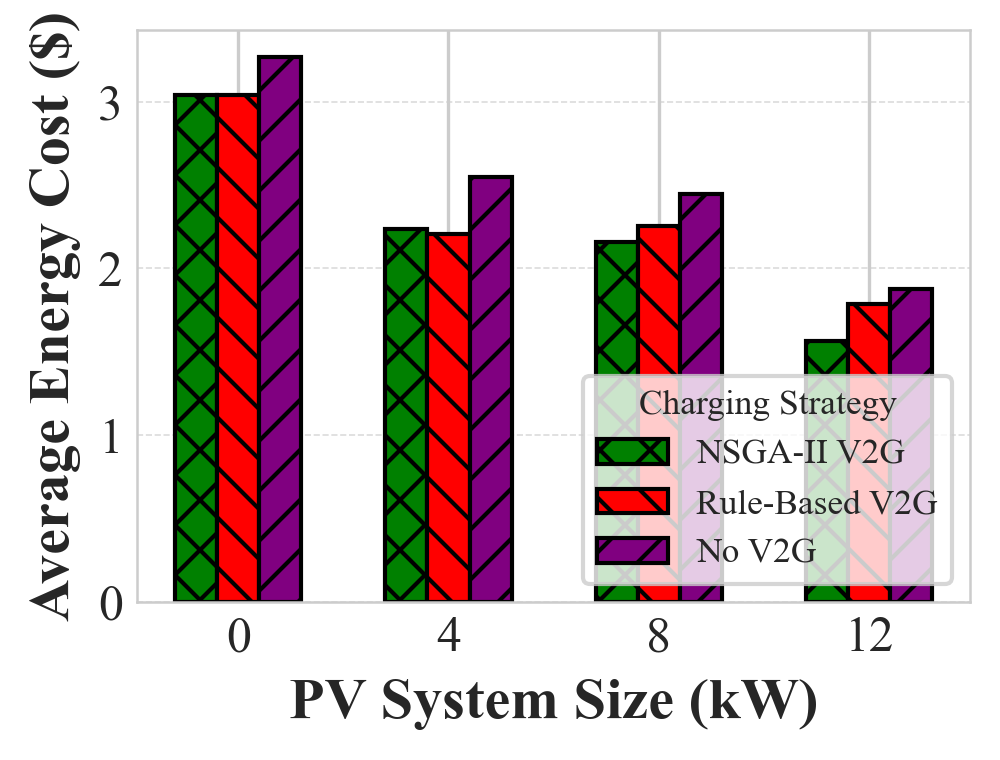

In [10]:
# ENERGY COST FOR PV SIZES
cols = ['nsga_energy_cost', 'rulebased_energy_cost', 'no_v2g_energy_cost']
pv_order = [0, 4, 8, 12]
grouped = pv_results.groupby('pv_size')[cols].mean().reindex(pv_order)

# Plot grouped bars
x = np.arange(len(grouped))  # positions for pv sizes
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
nsga_e_pv = ax.bar(x - width, grouped['nsga_energy_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
rb_e_pv = ax.bar(x, grouped['rulebased_energy_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
uc_e_pv = ax.bar(x + width, grouped['no_v2g_energy_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
ax.set_xlabel('PV System Size (kW)')
ax.set_ylabel('Average Energy Cost ($)')
# ax.set_title('Average Energy Cost by PV System Size and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='lower right') #, borderaxespad=0.5, bbox_to_anchor=(0.01, 0.86))
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.2f', padding=3)
plt.show()

In [11]:
# get exact values for each bar
nsga_pv_vals = [rect.get_height() for rect in nsga_e_pv]
print("nsga_pv_vals: ", nsga_pv_vals)
rb_pv_vals = [rect.get_height() for rect in rb_e_pv]
print("rb_pv_vals: ", rb_pv_vals)
uc_pv_vals = [rect.get_height() for rect in uc_e_pv]
print("uc_pv_vals: ", uc_pv_vals)


nsga_pv_vals:  [np.float64(3.0422604545182357), np.float64(2.2369048305209027), np.float64(2.157553982999111), np.float64(1.562557814790883)]
rb_pv_vals:  [np.float64(3.041237193696032), np.float64(2.208735657477832), np.float64(2.2517638085146507), np.float64(1.7861308426737397)]
uc_pv_vals:  [np.float64(3.2666370674629635), np.float64(2.5456766845297962), np.float64(2.4461193629516687), np.float64(1.8754361561838495)]


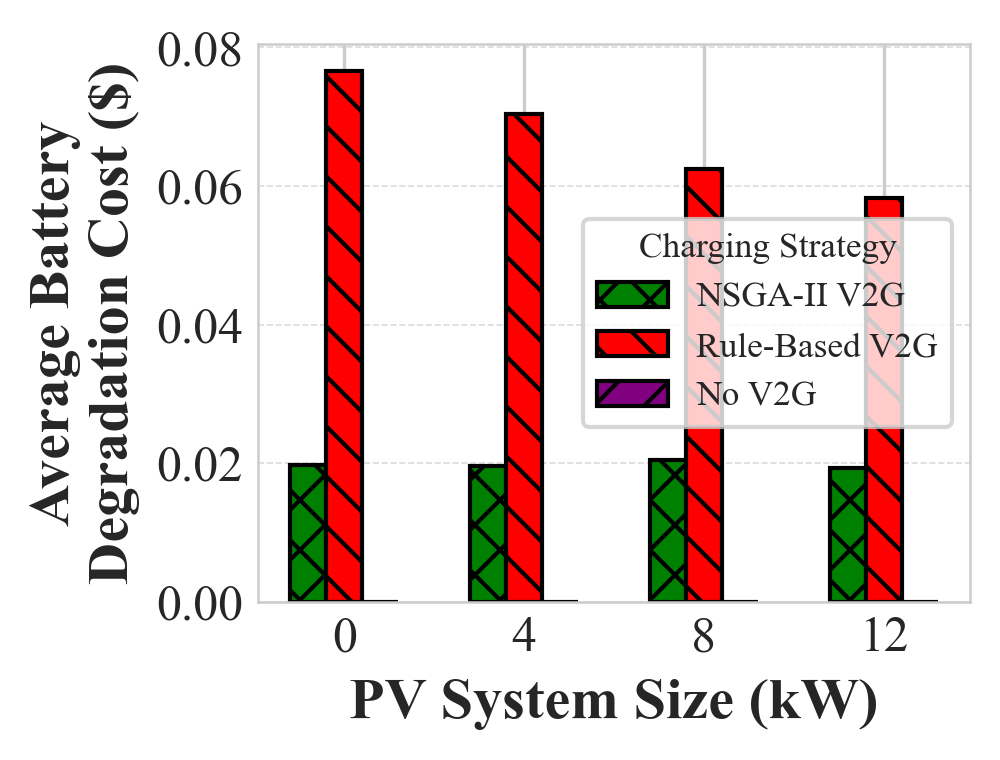

In [12]:
# BATTERY DEGRADATION COST FOR PV SIZES
cols = ['nsga_batt_deg_cost', 'rulebased_batt_deg_cost', 'no_v2g_batt_deg_cost']
pv_order = [0, 4, 8, 12]
grouped = pv_results.groupby('pv_size')[cols].mean().reindex(pv_order)

# Plot grouped bars
x = np.arange(len(grouped))  # positions for pv sizes
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, grouped['nsga_batt_deg_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, grouped['rulebased_batt_deg_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, grouped['no_v2g_batt_deg_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
ax.set_xlabel('PV System Size (kW)')
ax.set_ylabel('Average Battery\nDegradation Cost ($)')
# ax.set_title('Average Battery Degradation Cost by PV System Size and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='center right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
# plt.savefig('final_plots/pv_sizes_batt_deg_cost.png')
plt.show()

**DIFFERENT HOME LOADS**

In [13]:
home_loads = pd.read_csv('../results/varying_home_size_exp/all_results_home_loads_experiments.csv')
home_loads.shape

(210, 43)

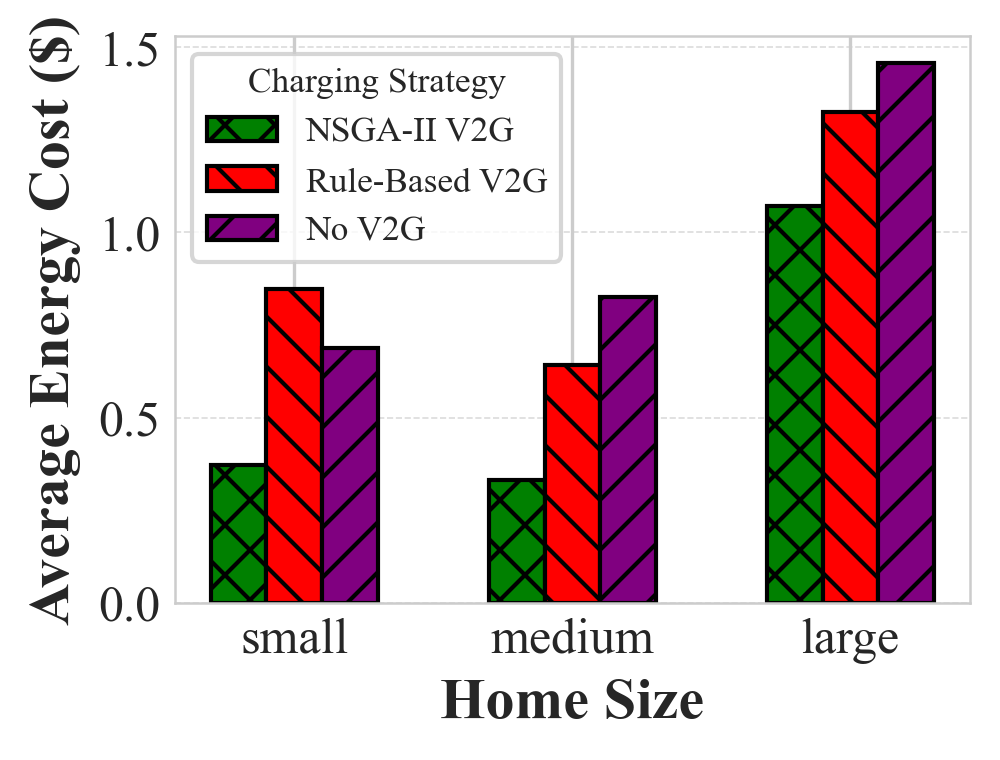

In [14]:
# ENERGY COST FOR HOME SIZES

cols = ['nsga_energy_cost', 'rulebased_energy_cost', 'no_v2g_energy_cost']
home_order = ['small', 'med', 'large']
grouped = home_loads.groupby('home_size')[cols].mean().reindex(home_order)

# Plot grouped bars
x = np.arange(len(grouped))  # positions for pv sizes
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, grouped['nsga_energy_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, grouped['rulebased_energy_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, grouped['no_v2g_energy_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels([label.replace('med', 'medium') for label in grouped.index])
ax.set_xlabel('Home Size')
ax.set_ylabel('Average Energy Cost ($)')
# ax.set_title('Average Energy Cost by Home Size and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='upper left')
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/home_sizes_energy_costs.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
plt.show()

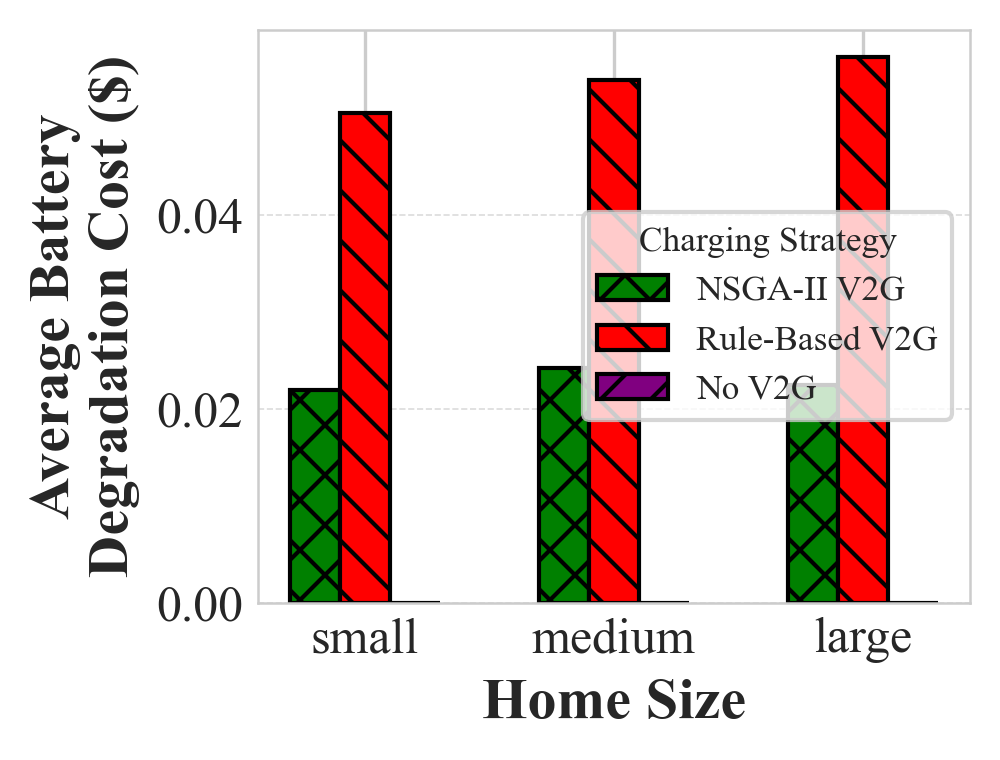

In [15]:
# BATT DEGRADATION COST FOR HOME SIZES
cols = ['nsga_batt_deg_cost', 'rulebased_batt_deg_cost', 'no_v2g_batt_deg_cost']
home_order = ['small', 'med', 'large']
grouped = home_loads.groupby('home_size')[cols].mean().reindex(home_order)

# Plot grouped bars
x = np.arange(len(grouped))  # positions for pv sizes
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, grouped['nsga_batt_deg_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, grouped['rulebased_batt_deg_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, grouped['no_v2g_batt_deg_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels([label.replace('med', 'medium') for label in grouped.index])
ax.set_xlabel('Home Size')
ax.set_ylabel('Average Battery\nDegradation Cost ($)')

# ax.set_title('Average Battery Degradation Cost by Home Size and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='center right') #, bbox_to_anchor=(1, 0.9))
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/home_sizes_batt_deg_costs.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
plt.show()

**BATTERY SIZES**

In [16]:
batt_size_results = pd.read_csv('../results/varying_batt_sizes_exp/all_results_batt_sizes_experiments.csv')
batt_size_results.shape

(420, 43)

In [17]:
batt_size_results.head()

,population_size,generations,crossover_rate,mutation_rate,"start_time(month,day,hr)",soc_arrival,soc_target,soh_initial,b_max,r_cmax,...,no_v2g_dods,rulebased_charging_schedule,rulebased_total_cost,rulebased_energy_cost,rulebased_batt_deg_cost,rulebased_socs,rulebased_sohs,rulebased_dods,rulebased_net_load,duration_of_experiment
0,150,200,0.85,0.07,"1,7,0",0.440061,0.8,0.908761,60,2.75,...,[0.55993852 0.51410519 0.46827186 0.42243852 0...,"[2.75, 2.75, 2.75, 2.75, 2.75, 2.75, -2.75, 2....",3.738718,3.655490,0.083228,[0.44006148 0.48589481 0.53172814 0.57756148 0...,[0.90876085 0.90876085 0.90876085 0.90876085 0...,[0.55993852 0.51410519 0.46827186 0.42243852 0...,"[np.float64(-3.3071777777777775), np.float64(-...",0:00:00
1,150,200,0.85,0.07,"1,7,0",0.607767,0.8,0.925883,70,2.75,...,[0.39223301 0.3529473 0.31366158 0.27437587 0...,"[2.75, 2.75, 2.75, -2.75, 2.75, -2.75, 2.75, -...",2.905465,2.812764,0.092701,[0.60776699 0.6470527 0.68633842 0.72562413 0...,[0.92588329 0.92588329 0.92588329 0.92588329 0...,[0.39223301 0.3529473 0.31366158 0.27437587 0...,"[np.float64(-3.3071777777777775), np.float64(-...",00:00.0
2,150,200,0.85,0.07,"1,7,0",0.945870,0.8,0.944380,80,2.75,...,[0.05412962 0.05412962 0.05412962 0.05412962 0...,"[-2.75, -2.75, -2.75, -2.75, -2.75, -2.75, -2....",0.805308,0.719402,0.085906,[0.94587038 0.91149538 0.87712038 0.84274538 0...,[0.94437977 0.94437567 0.94437156 0.94436746 0...,[0.05412962 0.08850462 0.12287962 0.15725462 0...,"[np.float64(-1.8081), np.float64(-1.815), np.f...",00:00.0
3,150,200,0.85,0.07,"1,7,0",0.890777,0.8,0.880684,90,2.75,...,[0.1092233 0.1092233 0.1092233 0.1092233 0.109...,"[-2.75, -2.75, -2.75, -2.75, -2.75, -2.75, -2....",1.227230,1.144585,0.082646,[0.8907767 0.86022114 0.82966559 0.79911003 0...,[0.8806839 0.8806798 0.8806757 0.88067026 0...,[0.1092233 0.13977886 0.17033441 0.20088997 0...,"[np.float64(-1.8081), np.float64(-1.815), np.f...",0:00:00
4,150,200,0.85,0.07,"1,7,0",0.802659,0.8,0.946386,100,2.75,...,[0.19734138 0.19734138 0.19734138 0.19734138 0...,"[-2.75, -2.75, -2.75, -2.75, 2.75, -2.75, 2.75...",1.645866,1.558279,0.087588,[0.80265862 0.77515862 0.74765862 0.72015862 0...,[0.94638568 0.94637875 0.94636912 0.94635439 0...,[0.19734138 0.22484138 0.25234138 0.27984138 0...,"[np.float64(-1.8081), np.float64(-1.815), np.f...",0:00:00


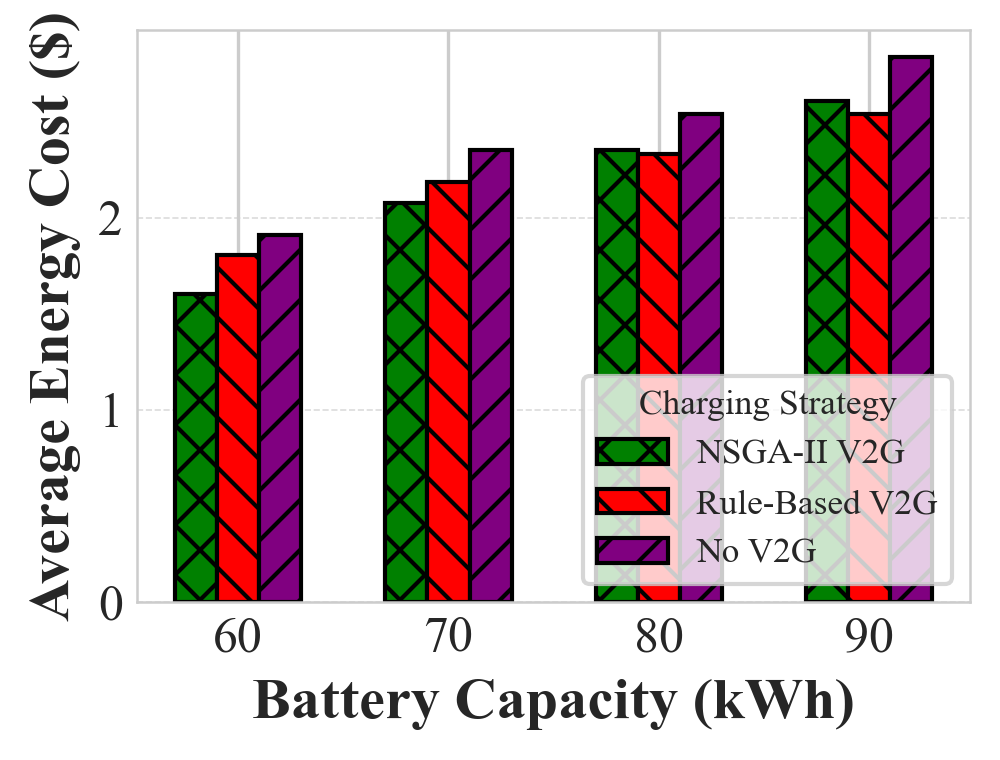

In [18]:
# ENERGY COST
cols = ['nsga_energy_cost', 'rulebased_energy_cost', 'no_v2g_energy_cost']
batt_size_order = [60, 70, 80, 90]
grouped = batt_size_results.groupby('b_max')[cols].mean().reindex(batt_size_order)

# Plot grouped bars
x = np.arange(len(grouped))  # positions for pv sizes
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, grouped['nsga_energy_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, grouped['rulebased_energy_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, grouped['no_v2g_energy_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
ax.set_xlabel('Battery Capacity (kWh)')
ax.set_ylabel('Average Energy Cost ($)')
# ax.set_title('Average Energy Cost by Battery Capacity and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='lower right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/batt_capacity_energy_cost.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
plt.show()

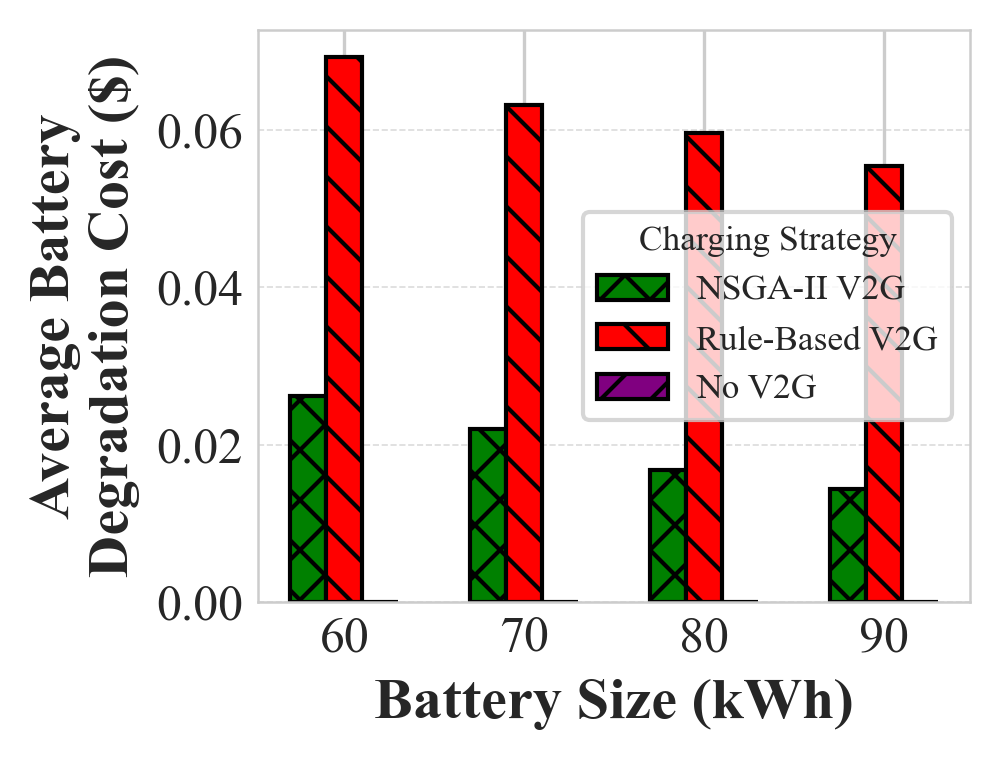

In [19]:
# BATT DEGRADATION COST
cols = ['nsga_batt_deg_cost', 'rulebased_batt_deg_cost', 'no_v2g_batt_deg_cost']
batt_size_order = [60, 70, 80, 90]
grouped = batt_size_results.groupby('b_max')[cols].mean().reindex(batt_size_order)

# Plot grouped bars
x = np.arange(len(grouped))  # positions for pv sizes
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, grouped['nsga_batt_deg_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, grouped['rulebased_batt_deg_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, grouped['no_v2g_batt_deg_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
ax.set_xlabel('Battery Size (kWh)')
ax.set_ylabel('Average Battery\nDegradation Cost ($)')
# ax.set_title('Average Battery Degradation Cost by Battery Size and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='center right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
# plt.savefig('final_plots/batt_capacity_batt_deg_cost.png')
plt.show()


**VARYING TARGET SOCS**

In [20]:
soc_targets_horizon6 = pd.read_csv('../results/varying_target_socs_exp/all_results_soc_targets_experiments.csv')
print(soc_targets_horizon6.shape)

(432, 46)


In [21]:
soc_targets_horizon6.columns

Index(['time_horizon', 'population_size', 'generations', 'crossover_rate',
       'mutation_rate', 'start_time(month,day,hr)', 'soc_arrival',
       'soc_target', 'soh_initial', 'b_max', 'r_cmax', 'r_dmin',
       'energy_cost_model', 'p_load', 'p_pv', 'energy_buying_costs',
       'energy_selling_costs', 'home_size', 'home_id', 'pv_size',
       'nsga_net_load', 'nsga_solution', 'nsga_total_cost', 'nsga_energy_cost',
       'nsga_batt_deg_cost', 'nsga_socs', 'nsga_sohs', 'nsga_dods',
       'pareto_objectives', 'duration_of_experiment',
       'no_v2g_charging_schedule', 'no_v2g_total_cost', 'no_v2g_energy_cost',
       'no_v2g_batt_deg_cost', 'no_v2g_socs', 'no_v2g_sohs', 'no_v2g_dods',
       'rulebased_charging_schedule', 'rulebased_total_cost',
       'rulebased_energy_cost', 'rulebased_batt_deg_cost', 'rulebased_socs',
       'rulebased_sohs', 'rulebased_dods', 'rulebased_net_load',
       'duration_of_experiment.1'],
      dtype='object')

In [22]:
import ast
import re

def _extract_last_soc(val):
    # handle already-parsed lists/arrays
    if isinstance(val, (list, tuple)):
        try:
            return float(val[-1])
        except Exception:
            return float("nan")
    # handle pandas/np types and NaN
    try:
        if pd.isna(val):
            return float("nan")
    except Exception:
        pass

    s = str(val).strip()

    # remove np.float64(...) wrappers if present
    s = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    # Try safe Python literal eval first
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple)):
            return float(parsed[-1])
        if isinstance(parsed, (float, int)):
            return float(parsed)
        # fallback for other indexable objects
        try:
            return float(parsed[-1])
        except Exception:
            return float("nan")
    except Exception:
        # Fall back to whitespace/comma separated parsing (handles "[0.1 0.2 0.3]" or "0.1 0.2")
        s2 = s.strip("[]()")
        tokens = re.split(r"[\s,]+", s2.strip())
        tokens = [t for t in tokens if t != ""]
        try:
            return float(tokens[-1])
        except Exception:
            return float("nan")

soc_targets_horizon6['nsga_soc_final'] = soc_targets_horizon6['nsga_socs'].apply(_extract_last_soc)
soc_targets_horizon6['uc_soc_final'] = soc_targets_horizon6['no_v2g_socs'].apply(_extract_last_soc)
soc_targets_horizon6['rb_soc_final'] = soc_targets_horizon6['rulebased_socs'].apply(_extract_last_soc)


In [23]:
soc_targets_horizon6['nsga_utility_frac'] = soc_targets_horizon6['nsga_soc_final'] / soc_targets_horizon6['soc_target']
soc_targets_horizon6['rb_utility_frac'] = soc_targets_horizon6['rb_soc_final'] / soc_targets_horizon6['soc_target']
soc_targets_horizon6['uc_utility_frac'] = [min(1.0, soc) for soc in (soc_targets_horizon6['uc_soc_final'] / soc_targets_horizon6['soc_target'])]
soc_targets_horizon6.head()


,time_horizon,population_size,generations,crossover_rate,mutation_rate,"start_time(month,day,hr)",soc_arrival,soc_target,soh_initial,b_max,...,rulebased_sohs,rulebased_dods,rulebased_net_load,duration_of_experiment.1,nsga_soc_final,uc_soc_final,rb_soc_final,nsga_utility_frac,rb_utility_frac,uc_utility_frac
0,6,150,200,0.85,0.07,"5,7,0",0.724594,0.75,0.948804,76.1,...,[0.94880404 0.94878299 0.94878299 0.94874186 0...,[0.27540638 0.31154304 0.27540638 0.31154304 0...,"[np.float64(-2.263), np.float64(-2.85227777777...",00:00.0,0.749978,0.760730,0.688457,0.999970,0.917943,1.0
1,6,150,200,0.85,0.07,"5,7,0",0.565008,0.75,0.960919,76.1,...,[0.96091859 0.96091859 0.96091859 0.96091859 0...,[0.43499197 0.39885531 0.36271865 0.32658199 0...,"[np.float64(-2.8522777777777777), np.float64(-...",00:00.0,0.749986,0.781828,0.673418,0.999981,0.897891,1.0
2,6,150,200,0.85,0.07,"5,7,0",0.614512,0.75,0.963225,76.1,...,[0.96322462 0.96322462 0.96322462 0.96322462 0...,[0.38548831 0.34935165 0.31321498 0.27707832 0...,"[np.float64(-2.8522777777777777), np.float64(-...",0:00:00,0.749918,0.759058,0.722922,0.999890,0.963896,1.0
3,6,150,200,0.85,0.07,"5,7,0",0.217600,0.75,0.991843,76.1,...,[0.99184311 0.99184311 0.99184311 0.99184311 0...,[0.78239963 0.74626296 0.7101263 0.67398964 0...,"[np.float64(-2.8522777777777777), np.float64(-...",00:00.0,0.749920,0.761367,0.687377,0.999894,0.916503,1.0
4,6,150,200,0.85,0.07,"5,7,0",0.276505,0.75,0.982586,76.1,...,[0.9825863 0.9825863 0.9825863 0.9825863 0...,[0.72349506 0.6873584 0.65122173 0.61508507 0...,"[np.float64(-2.8522777777777777), np.float64(-...",0:00:00,0.749999,0.761367,0.674008,0.999998,0.898678,1.0


In [24]:
grouped_targets = soc_targets_horizon6.groupby('soc_target')
nsga_final_soc = {}
nsga_utility_frac ={}
totals = {}
nsga_energy_costs_t = {}
nsga_batt_deg_costs_t = {}
uc_utility_frac ={}
uc_final_soc = {}
uc_energy_costs_t = {}
uc_batt_deg_costs_t = {}
rb_utility_frac ={}
rb_final_soc = {}
rb_energy_costs_t = {}
rb_batt_deg_costs_t = {}

for target, grp in grouped_targets:
    totals[target] = len(grp) * target
    nsga_final_soc[target] = grp['nsga_soc_final'].sum()
    nsga_utility_frac[target] = grp['nsga_utility_frac'].median()
    nsga_energy_costs_t[target] = grp['nsga_energy_cost'].mean()
    nsga_batt_deg_costs_t[target] = grp['nsga_batt_deg_cost'].mean()

    uc_final_soc[target] = grp['uc_soc_final'].sum()
    uc_utility_frac[target] = grp['uc_utility_frac'].median()
    uc_energy_costs_t[target] = grp['no_v2g_energy_cost'].mean()
    uc_batt_deg_costs_t[target] = grp['no_v2g_batt_deg_cost'].mean()    

    rb_final_soc[target] = grp['rb_soc_final'].sum()
    rb_utility_frac[target] = grp['rb_utility_frac'].median()
    rb_energy_costs_t[target] = grp['rulebased_energy_cost'].mean()
    rb_batt_deg_costs_t[target] = grp['rulebased_batt_deg_cost'].mean()    



target_met_df = pd.DataFrame({
    'total_rows': pd.Series(totals),
    'nsga_total_final_soc': pd.Series(nsga_final_soc),
    'nsga_energy_cost': pd.Series(nsga_energy_costs_t),
    'nsga_batt_deg_cost': pd.Series(nsga_batt_deg_costs_t),
    'uc_total_final_soc': pd.Series(uc_final_soc),
    'uc_energy_cost': pd.Series(uc_energy_costs_t),
    'uc_batt_deg_cost': pd.Series(uc_batt_deg_costs_t),
    'rb_total_final_soc': pd.Series(rb_final_soc),
    'rb_energy_cost': pd.Series(rb_energy_costs_t),
    'rb_batt_deg_cost': pd.Series(rb_batt_deg_costs_t),
    'nsga_utility_frac': pd.Series(nsga_utility_frac),
    'rb_utility_frac': pd.Series(rb_utility_frac),
    'uc_utility_frac': pd.Series(uc_utility_frac),

})
target_met_df['nsga_percent_of_target_met'] = target_met_df['nsga_total_final_soc'] * 100.0 / target_met_df['total_rows']
target_met_df['uc_percent_of_target_met'] = [min(100.0, soc) for soc in (target_met_df['uc_total_final_soc'] * 100.0 / target_met_df['total_rows'])]
target_met_df['rb_percent_of_target_met'] = target_met_df['rb_total_final_soc'] * 100.0 / target_met_df['total_rows']

target_met_df['nsga_utility_normalized_energy_cost'] = target_met_df['nsga_energy_cost']/target_met_df['nsga_utility_frac']
target_met_df['rb_utility_normalized_energy_cost'] = target_met_df['rb_energy_cost']/target_met_df['rb_utility_frac']
target_met_df['uc_utility_normalized_energy_cost'] = target_met_df['uc_energy_cost']/target_met_df['uc_utility_frac']


target_met_df['nsga_utility_normalized_batt_deg_cost'] = target_met_df['nsga_batt_deg_cost']/target_met_df['nsga_utility_frac']
target_met_df['rb_utility_normalized_batt_deg_cost'] = target_met_df['rb_batt_deg_cost']/target_met_df['rb_utility_frac']
target_met_df['uc_utility_normalized_batt_deg_cost'] = target_met_df['uc_batt_deg_cost']/target_met_df['uc_utility_frac']


target_met_df = target_met_df.drop([1.00])
target_met_df

,total_rows,nsga_total_final_soc,nsga_energy_cost,nsga_batt_deg_cost,uc_total_final_soc,uc_energy_cost,uc_batt_deg_cost,rb_total_final_soc,rb_energy_cost,rb_batt_deg_cost,...,uc_utility_frac,nsga_percent_of_target_met,uc_percent_of_target_met,rb_percent_of_target_met,nsga_utility_normalized_energy_cost,rb_utility_normalized_energy_cost,uc_utility_normalized_energy_cost,nsga_utility_normalized_batt_deg_cost,rb_utility_normalized_batt_deg_cost,uc_utility_normalized_batt_deg_cost
0.75,54.0,53.997969,1.242817,0.036562,55.084621,1.449123,0.0,51.594568,1.768218,0.057695,...,1.0,99.996239,100.0,95.545496,1.242859,1.834450,1.449123,0.036563,0.059856,0.0
0.80,57.6,57.596959,1.668540,0.021715,59.421021,1.916687,0.0,53.003898,1.898734,0.048474,...,1.0,99.994720,100.0,92.020656,1.668613,2.101178,1.916687,0.021716,0.053642,0.0
0.85,61.2,61.196430,2.067314,0.014959,62.456500,2.254990,0.0,53.943451,1.980961,0.045427,...,1.0,99.994167,100.0,88.142894,2.067407,2.329183,2.254990,0.014960,0.053412,0.0
0.90,64.8,64.795930,2.431419,0.011118,65.491980,2.589883,0.0,55.244371,2.124265,0.044274,...,1.0,99.993720,100.0,85.253659,2.431523,2.644599,2.589883,0.011119,0.055118,0.0
0.95,68.4,68.396729,2.859125,0.006049,70.262019,3.104054,0.0,56.978931,2.325427,0.043384,...,1.0,99.995218,100.0,83.302530,2.859227,3.041196,3.104054,0.006049,0.056738,0.0


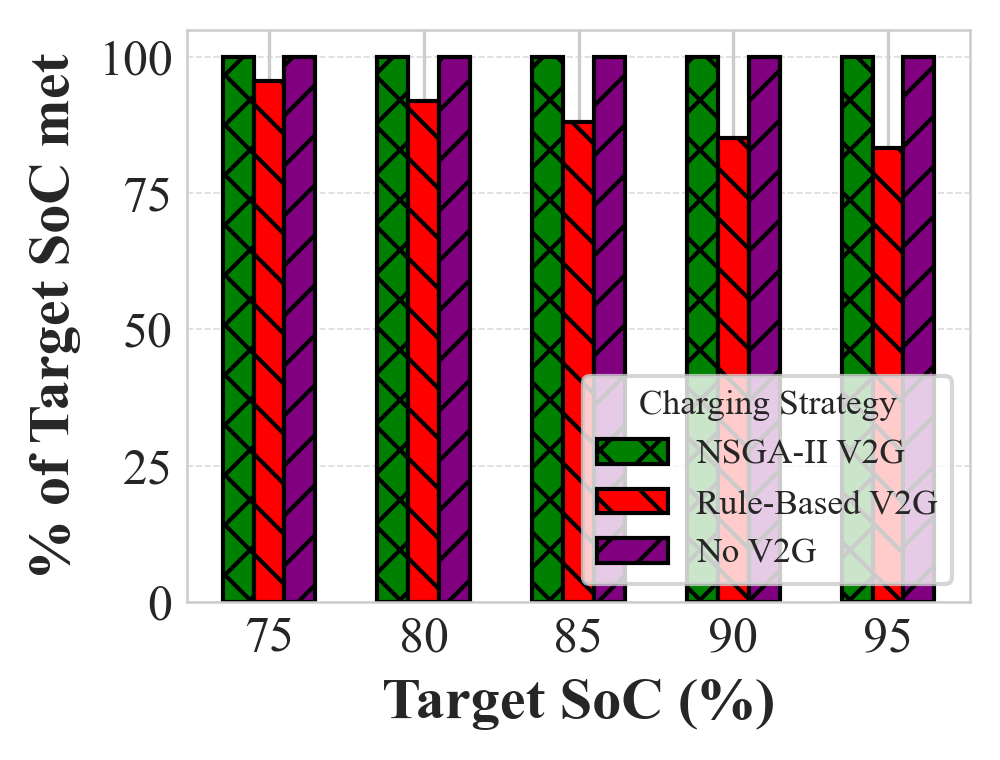

In [25]:
soc_targets = [0.75, 0.8, 0.85, 0.9, 0.95]
x = np.arange(len(soc_targets))
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, target_met_df['nsga_percent_of_target_met'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, target_met_df['rb_percent_of_target_met'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, target_met_df['uc_percent_of_target_met'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels([int(idx*100) for idx in target_met_df.index])
ax.set_xlabel('Target SoC (%)')
ax.set_ylabel('% of Target SoC met')
# ax.set_title('Average Energy Cost by Battery Capacity and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='lower right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/batt_capacity_energy_cost.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.2f', padding=3)
plt.show()

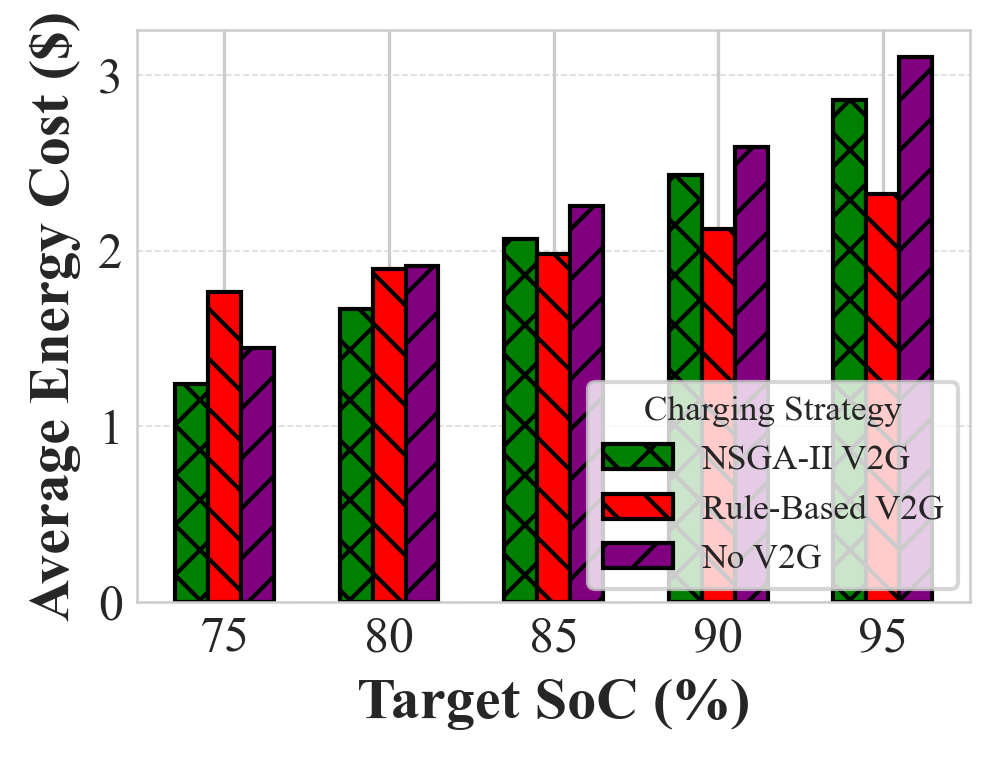

In [26]:
soc_targets = [0.75, 0.8, 0.85, 0.9, 0.95]
x = np.arange(len(target_met_df))
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, target_met_df['nsga_energy_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, target_met_df['rb_energy_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, target_met_df['uc_energy_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels([int(idx*100) for idx in target_met_df.index])
ax.set_xlabel('Target SoC (%)')
ax.set_ylabel('Average Energy Cost ($)')
# ax.set_title('Average Energy Cost by Battery Capacity and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='lower right', borderaxespad=0.35)
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/batt_capacity_energy_cost.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
plt.show()

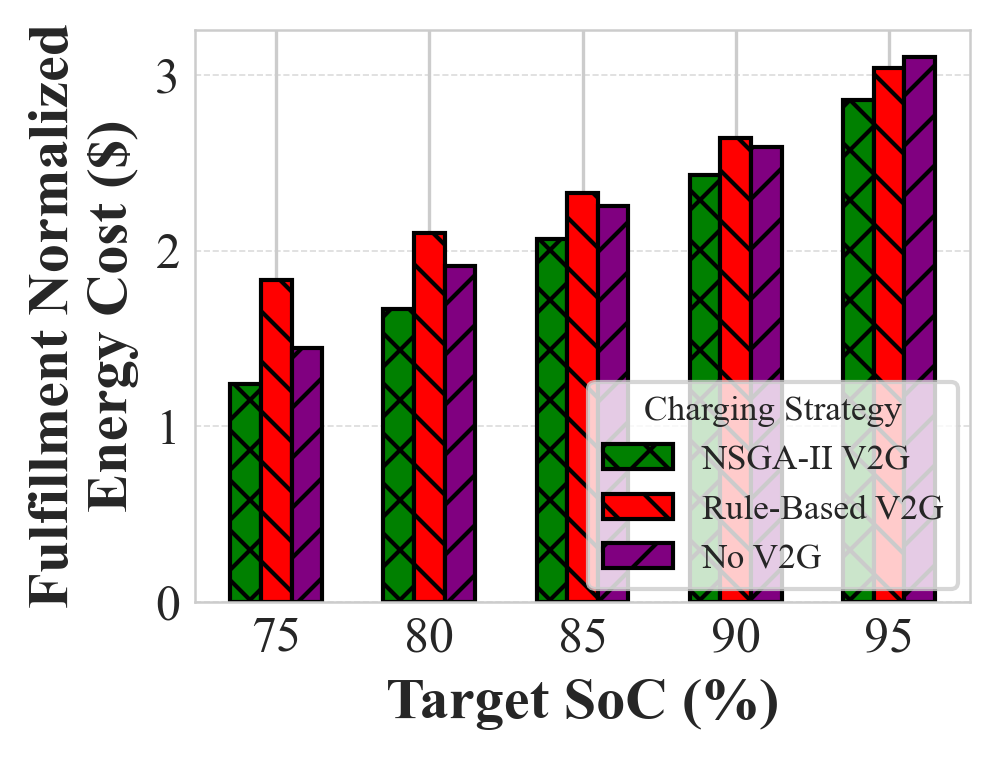

In [30]:
soc_targets = [0.75, 0.8, 0.85, 0.9, 0.95]
x = np.arange(len(target_met_df))
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
nsga_e = ax.bar(x - width, target_met_df['nsga_utility_normalized_energy_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
rb_e = ax.bar(x, target_met_df['rb_utility_normalized_energy_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
uc_e = ax.bar(x + width, target_met_df['uc_utility_normalized_energy_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels([int(idx*100) for idx in target_met_df.index])
ax.set_xlabel('Target SoC (%)')
ax.set_ylabel('Fulfillment Normalized\nEnergy Cost ($)')
# ax.set_title('Average Energy Cost by Battery Capacity and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='lower right', borderaxespad=0.35)
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/batt_capacity_energy_cost.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.3f', padding=3)
plt.show()

In [28]:
nsga_vals = [rect.get_height() for rect in nsga_e]
print("nsga: ", nsga_vals)
rb_pv_vals = [rect.get_height() for rect in rb_e]
print("rb: ", rb_pv_vals)
uc_pv_vals = [rect.get_height() for rect in uc_e]
print("uc: ", uc_pv_vals)


nsga:  [np.float64(1.2428592298871355), np.float64(1.6686132185485998), np.float64(2.067406571117224), np.float64(2.4315230566560637), np.float64(2.8592272298610544)]
rb:  [np.float64(1.834449613034254), np.float64(2.1011782421182255), np.float64(2.3291834184336278), np.float64(2.6445993952037), np.float64(3.041195775210483)]
uc:  [np.float64(1.4491225187175933), np.float64(1.9166871242748225), np.float64(2.254990170606708), np.float64(2.5898833478947463), np.float64(3.1040542119968695)]


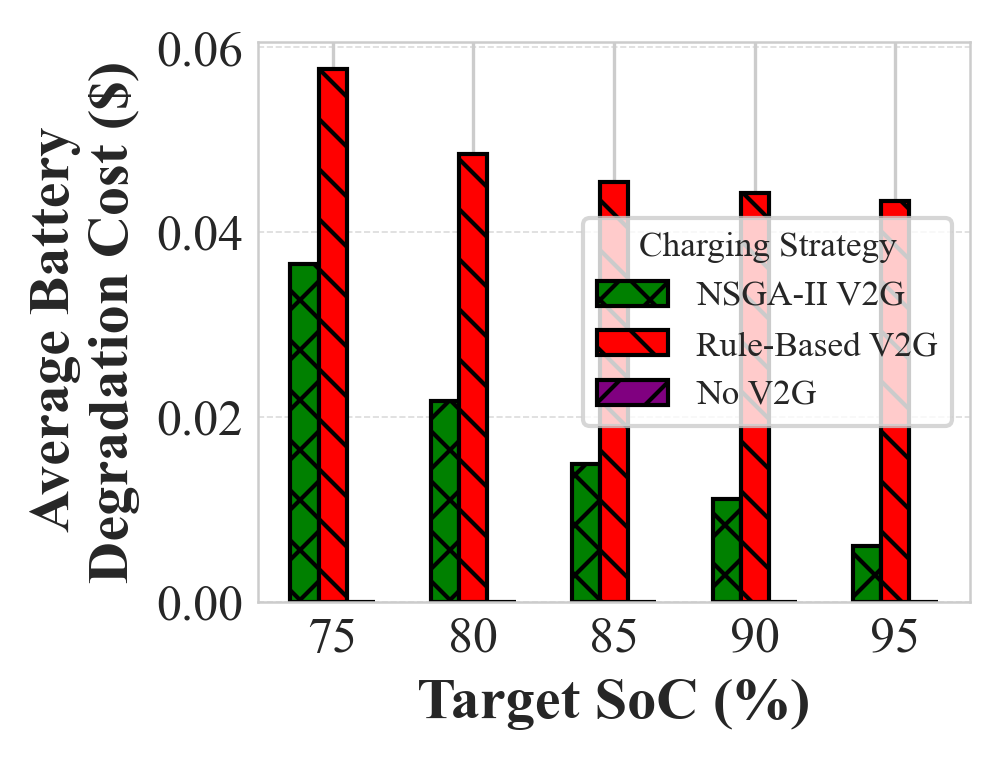

In [29]:
# BATTERY DEGRADATION COST

soc_targets = [0.75, 0.8, 0.85, 0.9, 0.95]
x = np.arange(len(target_met_df))
width = 0.2
hatches = ['xx', '\\\\', '//']  # You can use more: 'oo', '--', '++', '..'

fig, ax = plt.subplots()
ax.bar(x - width, target_met_df['nsga_batt_deg_cost'].values, width, label='NSGA-II V2G', color='green', edgecolor='black',  hatch=hatches[0])
ax.bar(x, target_met_df['rb_batt_deg_cost'].values, width, label='Rule-Based V2G', color='red', edgecolor='black', hatch=hatches[1])
ax.bar(x + width, target_met_df['uc_batt_deg_cost'].values, width, label='No V2G', color='purple', edgecolor='black',  hatch=hatches[2])

ax.set_xticks(x)
ax.set_xticklabels([int(idx*100) for idx in target_met_df.index])
ax.set_xlabel('Target SoC (%)')
ax.set_ylabel('Average Battery \nDegradation Cost ($)')
# ax.set_title('Average Energy Cost by Battery Capacity and Charging Strategy')
ax.legend(title='Charging Strategy', frameon=True, framealpha=0.8, loc='center right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout(pad=0.5)
# plt.savefig('final_plots/batt_capacity_energy_cost.png')
# for bars in ax.containers:
#     ax.bar_label(bars, fmt='%.2f', padding=3)
plt.show()